# DSS: recurrent smoothed and unsmoothed DMRs

`callDMR(DMLresult, delta=0, p.threshold=1e-5, minlen=50, minCG=3, dis.merge=100, pct.sig=0.5)`

##### Modules

In [23]:
import os
import pandas as pd
import numpy as np
from pybedtools import BedTool

from upsetplot import UpSet, from_indicators
from matplotlib_venn import venn2, venn2_circles
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Functions

In [2]:
def AddRegion(sets, region):
    if region:  # non-empty
        memberships.append(tuple(sets))
        counts.append(len(region))

##### Fonts & Colors

In [3]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# fig size
plt.rcParams['figure.figsize'] = (7, 7)

# font size
title_size = 20
label_size = 18
tick_size = 16

colors = plt.cm.Set2.colors

##### Inputs

In [8]:
DIR1 = '/scratch/eger/projects/MethSmoothEval/tissues/DSS'
DIR2 = '/scratch/eger/projects/MethSmoothEval/tissues/DM_analysis/DMRs_recurrent'

In [14]:
sample_pairs_dict = {
        'hg002_blood_v_Bulk_FC_Control_02': 'Blood1_5kHz_v_Brain1_5kHz',
        'PPMI_3404_v_HBCC_81951_FTX': 'Blood2_4kHz_v_Brain2_4kHz',
        'PPMI_3404_v_HBCC_82044_FTX': 'Blood2_4kHz_v_Brain3_4kHz'
}

In [27]:
comparison_cols = [
    "Blood1_5kHz_v_Brain1_5kHz",
    "Blood2_4kHz_v_Brain2_4kHz",
    "Blood2_4kHz_v_Brain3_4kHz",
]

In [35]:
smooth_overlap_file = os.path.join(DIR2, 'smooth_DMRs_overlap_across_3_pairs.tsv')
unsmooth_overlap_file = os.path.join(DIR2, 'unsmooth_DMRs_overlap_across_3_pairs.tsv')

smooth_dir_file = os.path.join(DIR2, 'smooth_DMRs_overlap_across_3_pairs_same_direction.tsv')
unsmooth_dir_file = os.path.join(DIR2, 'unsmooth_DMRs_overlap_across_3_pairs_same_direction.tsv')

smooth_mem_file = os.path.join(DIR2, 'smooth_DMRs_upset_membership_loci.tsv')
unsmooth_mem_file = os.path.join(DIR2, 'unsmooth_DMRs_upset_membership_loci.tsv')

smooth_mem_dir_file = os.path.join(DIR2, 'smooth_DMRs_upset_membership_loci_same_direction.tsv')
unsmooth_mem_dir_file = os.path.join(DIR2, 'unsmooth_DMRs_upset_membership_loci_same_direction.tsv')

In [36]:
# all overlapping DMRs
smooth_dmrs_overlap_df = pd.read_csv(smooth_overlap_file, sep='\t')
unsmooth_dmrs_overlap_df = pd.read_csv(unsmooth_overlap_file, sep='\t')

# overlapping DMRs with same direction in all 3 comparisons
smooth_dir_df = pd.read_csv(smooth_dir_file, sep='\t')
unsmooth_dir_df = pd.read_csv(unsmooth_dir_file, sep='\t')

# membership
smooth_dmrs_mem_df = pd.read_csv(smooth_mem_file, sep='\t')
unsmooth_dmrs_mem_df = pd.read_csv(unsmooth_mem_file, sep='\t')
smooth_dmrs_dir_mem_df = pd.read_csv(smooth_mem_dir_file, sep='\t')
unsmooth_dmrs_dir_mem_df = pd.read_csv(unsmooth_mem_dir_file, sep='\t')

In [37]:
# rename sample pairs
smooth_dmrs_mem_df = smooth_dmrs_mem_df.rename(columns=sample_pairs_dict)
unsmooth_dmrs_mem_df = unsmooth_dmrs_mem_df.rename(columns=sample_pairs_dict)
smooth_dmrs_dir_mem_df = smooth_dmrs_dir_mem_df.rename(columns=sample_pairs_dict)
unsmooth_dmrs_dir_mem_df = unsmooth_dmrs_dir_mem_df.rename(columns=sample_pairs_dict)

smooth_dmrs_mem_df['source_pair'] = smooth_dmrs_mem_df['source_pair'].map(sample_pairs_dict)
unsmooth_dmrs_mem_df['source_pair'] = unsmooth_dmrs_mem_df['source_pair'].map(sample_pairs_dict)
smooth_dmrs_dir_mem_df['source_pair'] = smooth_dmrs_dir_mem_df['source_pair'].map(sample_pairs_dict)
unsmooth_dmrs_dir_mem_df['source_pair'] = unsmooth_dmrs_dir_mem_df['source_pair'].map(sample_pairs_dict)

## Upset plots

### Smoothed DMRs

#### Overlap (ignore effect size direction)

In [38]:
# Ensure booleans
df_bool = smooth_dmrs_mem_df[comparison_cols].astype(bool)

# Build upset input: each row = one DMR, indicators = comparison membership
upset_data = from_indicators(comparison_cols, data=df_bool)

counts = (
    smooth_dmrs_mem_df[comparison_cols]
    .astype(bool)
    .groupby(comparison_cols)
    .size()
    .reset_index(name="n_DMRs")
    .sort_values("n_DMRs", ascending=False)
)

counts

,Blood1_5kHz_v_Brain1_5kHz,Blood2_4kHz_v_Brain2_4kHz,Blood2_4kHz_v_Brain3_4kHz,n_DMRs
6,True,True,True,200848
3,True,False,False,160870
2,False,True,True,65148
5,True,True,False,40976
4,True,False,True,25775
0,False,False,True,16272
1,False,True,False,15802


<Figure size 900x500 with 0 Axes>

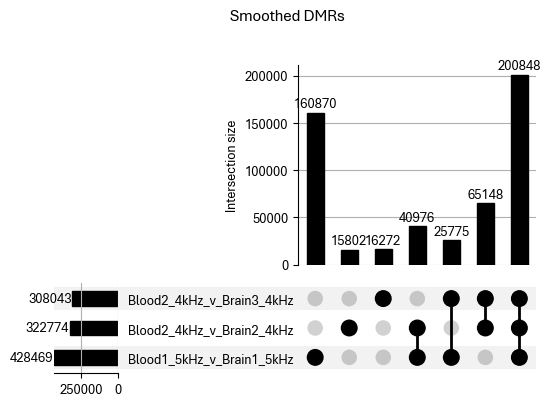

In [39]:
# Plot
plt.figure(figsize=(9, 5))
upset = UpSet(
    upset_data,
    subset_size="count",
    show_counts=True,
    sort_by="degree",      # groups unique, pairwise, and 3-way overlaps
    sort_categories_by=None
)
upset.plot()
plt.suptitle("Smoothed DMRs", y=1.02)
plt.show()

#### Overlap (only count DMRs that have same effect size direction as overlapping)

In [40]:
# Ensure booleans
df_bool = smooth_dmrs_dir_mem_df[comparison_cols].astype(bool)

# Build upset input: each row = one DMR, indicators = comparison membership
upset_data = from_indicators(comparison_cols, data=df_bool)

counts = (
    smooth_dmrs_dir_mem_df[comparison_cols]
    .astype(bool)
    .groupby(comparison_cols)
    .size()
    .reset_index(name="n_DMRs")
    .sort_values("n_DMRs", ascending=False)
)

counts

,Blood1_5kHz_v_Brain1_5kHz,Blood2_4kHz_v_Brain2_4kHz,Blood2_4kHz_v_Brain3_4kHz,n_DMRs
6,True,True,True,186630
3,True,False,False,169835
2,False,True,True,74176
5,True,True,False,36674
4,True,False,True,21151
0,False,False,True,18878
1,False,True,False,18347


<Figure size 900x500 with 0 Axes>

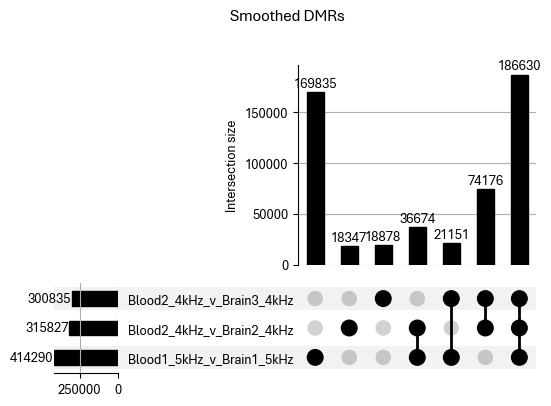

In [41]:
# Plot
plt.figure(figsize=(9, 5))
upset = UpSet(
    upset_data,
    subset_size="count",
    show_counts=True,
    sort_by="degree",      # groups unique, pairwise, and 3-way overlaps
    sort_categories_by=None
)
upset.plot()
plt.suptitle("Smoothed DMRs", y=1.02)
plt.show()

### Unsmoothed DMRs

#### Overlap (ignore effect size direction)

In [31]:
# Ensure booleans
df_bool = unsmooth_dmrs_mem_df[comparison_cols].astype(bool)

# Build upset input: each row = one DMR, indicators = comparison membership
upset_data = from_indicators(comparison_cols, data=df_bool)

counts = (
    unsmooth_dmrs_mem_df[comparison_cols]
    .astype(bool)
    .groupby(comparison_cols)
    .size()
    .reset_index(name="n_DMRs")
    .sort_values("n_DMRs", ascending=False)
)

counts

,Blood1_5kHz_v_Brain1_5kHz,Blood2_4kHz_v_Brain2_4kHz,Blood2_4kHz_v_Brain3_4kHz,n_DMRs
3,True,False,False,136455
2,False,True,True,13764
6,True,True,True,11745
5,True,True,False,6605
1,False,True,False,4369
4,True,False,True,3905
0,False,False,True,3611


<Figure size 900x500 with 0 Axes>

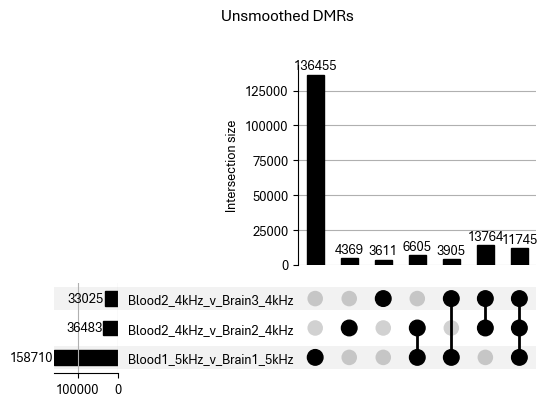

In [32]:
# Plot
plt.figure(figsize=(9, 5))
upset = UpSet(
    upset_data,
    subset_size="count",
    show_counts=True,
    sort_by="degree",      # groups unique, pairwise, and 3-way overlaps
    sort_categories_by=None
)
upset.plot()
plt.suptitle("Unsmoothed DMRs", y=1.02)
plt.show()

#### Overlap (only count DMRs that have same effect size direction as overlapping)

In [42]:
# Ensure booleans
df_bool = unsmooth_dmrs_dir_mem_df[comparison_cols].astype(bool)

# Build upset input: each row = one DMR, indicators = comparison membership
upset_data = from_indicators(comparison_cols, data=df_bool)

counts = (
    unsmooth_dmrs_dir_mem_df[comparison_cols]
    .astype(bool)
    .groupby(comparison_cols)
    .size()
    .reset_index(name="n_DMRs")
    .sort_values("n_DMRs", ascending=False)
)

counts

,Blood1_5kHz_v_Brain1_5kHz,Blood2_4kHz_v_Brain2_4kHz,Blood2_4kHz_v_Brain3_4kHz,n_DMRs
3,True,False,False,136480
2,False,True,True,13776
6,True,True,True,11727
5,True,True,False,6591
1,False,True,False,4377
4,True,False,True,3880
0,False,False,True,3623


<Figure size 900x500 with 0 Axes>

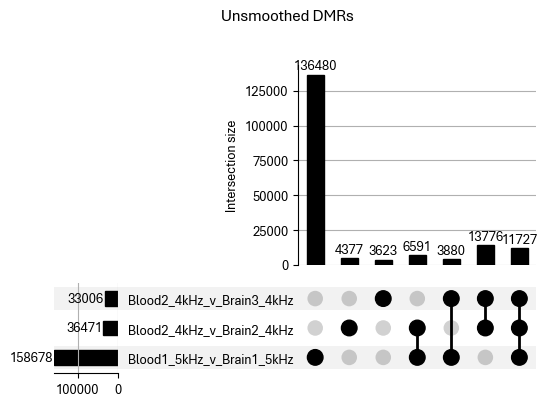

In [43]:
# Plot
plt.figure(figsize=(9, 5))
upset = UpSet(
    upset_data,
    subset_size="count",
    show_counts=True,
    sort_by="degree",      # groups unique, pairwise, and 3-way overlaps
    sort_categories_by=None
)
upset.plot()
plt.suptitle("Unsmoothed DMRs", y=1.02)
plt.show()